<a href="https://colab.research.google.com/github/Niranjan1422/Infosys_Internship/blob/Module_3/M3_Semantic_Search_%26_RAG_Pipelines_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import zipfile
import os

# Path to the ZIP file in Google Drive
zip_file_path = "/content/drive/MyDrive/Infosys_Datasets_Proj/archive (10).zip"
# Name of the specific CSV file inside the ZIP
csv_file_in_zip = "movies_metadata.csv"
# Temporary directory to extract the CSV
extract_dir = "/tmp/extracted_data"
extracted_csv_path = os.path.join(extract_dir, csv_file_in_zip)

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

try:
    # Open the ZIP file
    with zipfile.ZipFile(zip_file_path, 'r') as zf:
        # Check if the desired CSV file exists within the zip archive
        if csv_file_in_zip in zf.namelist():
            # Extract the specific CSV file
            zf.extract(csv_file_in_zip, extract_dir)
            # Read the extracted CSV file into a DataFrame
            df = pd.read_csv(extracted_csv_path)
            print(f"Successfully loaded '{csv_file_in_zip}' into a DataFrame.")
            print(f"DataFrame head:\n{df.head()}")
        else:
            print(f"Error: '{csv_file_in_zip}' not found inside '{zip_file_path}'.")
            print("Files available in the ZIP archive:", zf.namelist())
except FileNotFoundError:
    print(f"Error: The ZIP file '{zip_file_path}' was not found. Please ensure the path is correct and your Google Drive is mounted.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully loaded 'movies_metadata.csv' into a DataFrame.
DataFrame head:
   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False                                                NaN  65000000   
2  False  {'id': 119050, 'name': 'Grumpy Old Men Collect...         0   
3  False                                                NaN  16000000   
4  False  {'id': 96871, 'name': 'Father of the Bride Col...         0   

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   
2  [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...   
3  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...   
4                     [{'id': 35, 'name': 'Comedy'}]   

                               homepage     id    imdb_id original_language  \
0  http://toystory.disney.com/toy-story    862  tt0114709            

/tmp/ipython-input-4227732538.py:24: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(extracted_csv_path)


In [ ]:
pip install pandas networkx

In [ ]:
import pandas as pd
import networkx as nx
import json

# Load the movies metadata (the 'df' DataFrame is already loaded from the previous cell)
# Using the already loaded 'df' DataFrame for efficiency.
# If you needed to reload, you would use: movies = pd.read_csv(extracted_csv_path, low_memory=False)
movies = df.copy()

# Inspect to confirm columns
print(movies.columns[:10])

# Create directed graph
G = nx.DiGraph()

# Process first 500 movies for demo
movies_subset = movies.head(500)

for idx, row in movies_subset.iterrows():
    movie_id = row.get("id")
    title = row.get("title", "Unknown Title")
    language = row.get("original_language")

    # Add movie node
    G.add_node(movie_id, label="Movie", title=title)

    # Add language node & relation
    if pd.notna(language):
        G.add_node(language, label="Language")
        G.add_edge(movie_id, language, relation="IN_LANGUAGE")

    # Genres: stored as stringified JSON; parse if present
    genre_info = row.get("genres")
    if pd.notna(genre_info):
        try:
            genres = json.loads(genre_info.replace("'", '"'))
            for g in genres:
                genre_name = g.get("name")
                if genre_name:
                    G.add_node(genre_name, label="Genre")
                    G.add_edge(movie_id, genre_name, relation="HAS_GENRE")
        except:
            pass

    # Production companies similarly
    prod_info = row.get("production_companies")
    if pd.notna(prod_info):
        try:
            comps = json.loads(prod_info.replace("'", '"'))
            for comp in comps:
                comp_name = comp.get("name")
                if comp_name:
                    G.add_node(comp_name, label="ProductionCompany")
                    G.add_edge(movie_id, comp_name, relation="MADE_BY")
        except:
            pass

print("Nodes:", len(G.nodes()), "Edges:", len(G.edges()))

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview'],
      dtype='object')
Nodes: 1020 Edges: 2754


In [ ]:
genres = [n for n, d in G.nodes(data=True) if d.get("label") == "Genre"]
print("Genres in graph:", genres)

Genres in graph: ['Animation', 'Comedy', 'Family', 'Adventure', 'Fantasy', 'Romance', 'Drama', 'Action', 'Crime', 'Thriller', 'Horror', 'History', 'Science Fiction', 'Mystery', 'War', 'Foreign', 'Music', 'Documentary', 'Western', 'TV Movie']


In [ ]:
movie_to_query = "The Matrix"  # Example title
movie_nodes = [(n,d) for n,d in G.nodes(data=True) if d.get("label")=="Movie" and d.get("title")==movie_to_query]

if movie_nodes:
    node_id = movie_nodes[0][0]
    for s,t,d in G.out_edges(node_id, data=True):
        print(f"{movie_to_query} -[{d['relation']}]-> {t}")
else:
    print("Movie not in subset.")

Movie not in subset.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [ ]:
movie_to_query = "Clueless"  # Example title
movie_nodes = [(n,d) for n,d in G.nodes(data=True) if d.get("label")=="Movie" and d.get("title")==movie_to_query]

if movie_nodes:
    node_id = movie_nodes[0][0]
    for s,t,d in G.out_edges(node_id, data=True):
        print(f"{movie_to_query} -[{d['relation']}]-> {t}")
else:
    print("Movie not in subset.")

Clueless -[IN_LANGUAGE]-> en
Clueless -[HAS_GENRE]-> Comedy
Clueless -[HAS_GENRE]-> Drama
Clueless -[HAS_GENRE]-> Romance
Clueless -[MADE_BY]-> Paramount Pictures


In [ ]:
#Install Neo4j Python Driver in Colab

In [ ]:
pip install neo4j pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 7.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import zipfile
import os

# Reusing variables from the initial extraction in cell b87T10GGfF_N
zip_file_path = "/content/drive/MyDrive/Infosys_Datasets_Proj/archive (10).zip"
extract_dir = "/tmp/extracted_data"
# Ensure the extraction directory exists (it should from the previous cell, but good practice)
os.makedirs(extract_dir, exist_ok=True)

# 'movies_metadata.csv' is already loaded into `df` from the previous cell.
# We can assign it to `movies` for consistency with the cell's original intent.
movies = df.copy() # Use a copy if you intend to modify 'movies' independently later.

# Define the other CSV files to extract and load
csv_files_to_load = ["credits.csv", "keywords.csv"]
loaded_dataframes = {}

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zf:
        zip_contents = zf.namelist()
        for csv_file_name in csv_files_to_load:
            if csv_file_name in zip_contents:
                extracted_path = os.path.join(extract_dir, csv_file_name)
                zf.extract(csv_file_name, extract_dir)
                loaded_dataframes[csv_file_name.replace('.csv', '')] = pd.read_csv(extracted_path)
                print(f"Successfully loaded '{csv_file_name}'.")
            else:
                print(f"Error: '{csv_file_name}' not found inside '{zip_file_path}'.")
                print("Files available in the ZIP archive:", zip_contents)

    credits = loaded_dataframes.get('credits')
    keywords = loaded_dataframes.get('keywords')

    # Print shapes if all dataframes were successfully loaded
    if credits is not None and keywords is not None:
        print(movies.shape, credits.shape, keywords.shape)
    else:
        print("Some dataframes could not be loaded.")

except FileNotFoundError:
    print(f"Error: The ZIP file '{zip_file_path}' was not found. Please ensure the path is correct and your Google Drive is mounted.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully loaded 'credits.csv'.
Successfully loaded 'keywords.csv'.
(45466, 24) (45476, 3) (46419, 2)


In [ ]:
#Clean & Select Required Columns

movies = movies[['id','title','original_language','release_date','genres']]
credits = credits[['id','cast','crew']]
keywords = keywords[['id','keywords']]

movies = movies.dropna(subset=['id','title'])

In [ ]:
#Connect to Neo4j from Colab

from neo4j import GraphDatabase

URI = "neo4j+s://e27135de.databases.neo4j.io"
AUTH = ("neo4j", "WkmpufxtnWTdPav7XT1Ae9KD-_5H30FodCux9HlQLYY")

driver = GraphDatabase.driver(URI, auth=AUTH)

In [ ]:
def insert_movie(tx, movie_id, title, lang, date):
    tx.run("""
    MERGE (m:Movie {id:$id})
    SET m.title=$title,
        m.language=$lang,
        m.release_date=$date
    """, id=movie_id, title=title, lang=lang, date=date)

with driver.session() as session:
    for _, row in movies.head(1000).iterrows():  # demo subset
        session.execute_write(
            insert_movie,
            row['id'], row['title'],
            row['original_language'], row['release_date']
        )

In [ ]:
#Version

import neo4j
print(neo4j.__version__)

6.1.0


In [ ]:
movies_clean = movies.copy()

# Convert id to numeric and drop bad rows
movies_clean['id'] = pd.to_numeric(movies_clean['id'], errors='coerce')
movies_clean = movies_clean.dropna(subset=['id', 'title'])

# Convert id to int
movies_clean['id'] = movies_clean['id'].astype(int)

movies_clean = movies_clean.head(1000)
print(movies_clean.shape)

(1000, 5)


In [ ]:
from neo4j import GraphDatabase

URI = "neo4j+s://e27135de.databases.neo4j.io"
AUTH = ("neo4j", "WkmpufxtnWTdPav7XT1Ae9KD-_5H30FodCux9HlQLYY")

driver = GraphDatabase.driver(URI, auth=AUTH)

In [ ]:
#Insert Movies into Neo4j

def insert_movie(tx, movie_id, title, lang, date):
    tx.run(
        """
        MERGE (m:Movie {id: $id})
        SET m.title = $title,
            m.language = $lang,
            m.release_date = $date
        """,
        id=movie_id,
        title=title,
        lang=lang,
        date=date
    )

In [ ]:
with driver.session() as session:
    for _, row in movies_clean.iterrows():
        session.execute_write(
            insert_movie,
            row['id'],
            row['title'],
            row['original_language'],
            row['release_date']
        )

print("✅ Movies inserted successfully")

✅ Movies inserted successfully


In [ ]:
with driver.session() as session:
    result = session.run("RETURN 1 AS test")
    print(result.single()["test"])

1


In [ ]:
with driver.session() as session:
    session.run("""
        MERGE (m:Movie {id: 999999})
        SET m.title = 'Test Movie'
    """)
print("Single insert OK")

Single insert OK


In [ ]:
count = 0

with driver.session() as session:
    for _, row in movies_clean.head(50).iterrows():  # START SMALL
        session.run(
            """
            MERGE (m:Movie {id: $id})
            SET m.title = $title,
                m.language = $lang,
                m.release_date = $date
            """,
            id=int(row['id']),
            title=str(row['title']),
            lang=str(row['original_language']),
            date=str(row['release_date'])
        )
        count += 1

print(f"✅ Inserted {count} movies")

✅ Inserted 50 movies


In [ ]:
with driver.session() as session:
    for _, row in movies_clean.head(100).iterrows():
        session.run(
            """
            MERGE (m:Movie {id: $id})
            SET m.title = $title,
                m.language = $lang,
                m.release_date = $date
            """,
            id=int(row['id']),
            title=str(row['title']),
            lang=str(row['original_language']),
            date=str(row['release_date'])
        )

print("✅ Movies inserted successfully")

✅ Movies inserted successfully


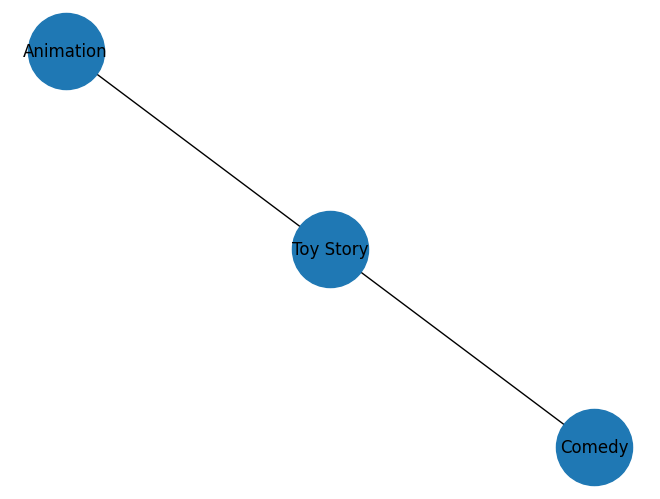

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_edge("Toy Story", "Animation")
G.add_edge("Toy Story", "Comedy")

nx.draw(G, with_labels=True, node_size=3000)
plt.show()

In [ ]:
with driver.session() as session:
    result = session.run("""
    CALL apoc.export.csv.query(
      "MATCH (m:Movie)-[:HAS_GENRE]->(g:Genre)
       RETURN m.title AS movie, g.name AS genre",
      null,
      {stream:true}
    )
    """)
    record = result.single()
    csv_data = record["data"]

with open("movies_genres.csv", "w", encoding="utf-8") as f:
    f.write(csv_data)

In [ ]:
query = """
MATCH (m:Movie)-[:HAS_GENRE]->(g:Genre)
RETURN m.title AS movie, g.name AS genre
LIMIT 500
"""

with driver.session() as session:
    result = session.run(query)
    df = pd.DataFrame([r.data() for r in result])

df.to_csv("movies_genres.csv", index=False)
df.head()

,movie,genre
0,Toy Story,Animation
1,Balto,Animation
2,Pocahontas,Animation
3,A Goofy Movie,Animation
4,Gumby: The Movie,Animation


In [ ]:
with driver.session() as session:
    session.run("CREATE CONSTRAINT movie_id IF NOT EXISTS FOR (m:Movie) REQUIRE m.id IS UNIQUE")
    session.run("CREATE CONSTRAINT person_name IF NOT EXISTS FOR (p:Person) REQUIRE p.name IS UNIQUE")

In [ ]:
movies_small = movies.head(200)  # for demo
movie_data = movies_small[["id", "title", "release_date"]].to_dict("records")

In [ ]:
def create_movies_batch(tx, movies):
    tx.run("""
        UNWIND $movies AS movie
        MERGE (m:Movie {id: movie.id})
        SET m.title = movie.title,
            m.release_date = movie.release_date
    """, movies=movies)

with driver.session() as session:
    session.execute_write(create_movies_batch, movie_data)

print("✅ Movies inserted successfully")

✅ Movies inserted successfully


In [ ]:
from tqdm import tqdm

batch_size = 50

for i in tqdm(range(0, len(movie_data), batch_size)):
    batch = movie_data[i:i+batch_size]
    with driver.session() as session:
        session.execute_write(create_movies_batch, batch)

100%|██████████| 4/4 [00:00<00:00,  6.61it/s]


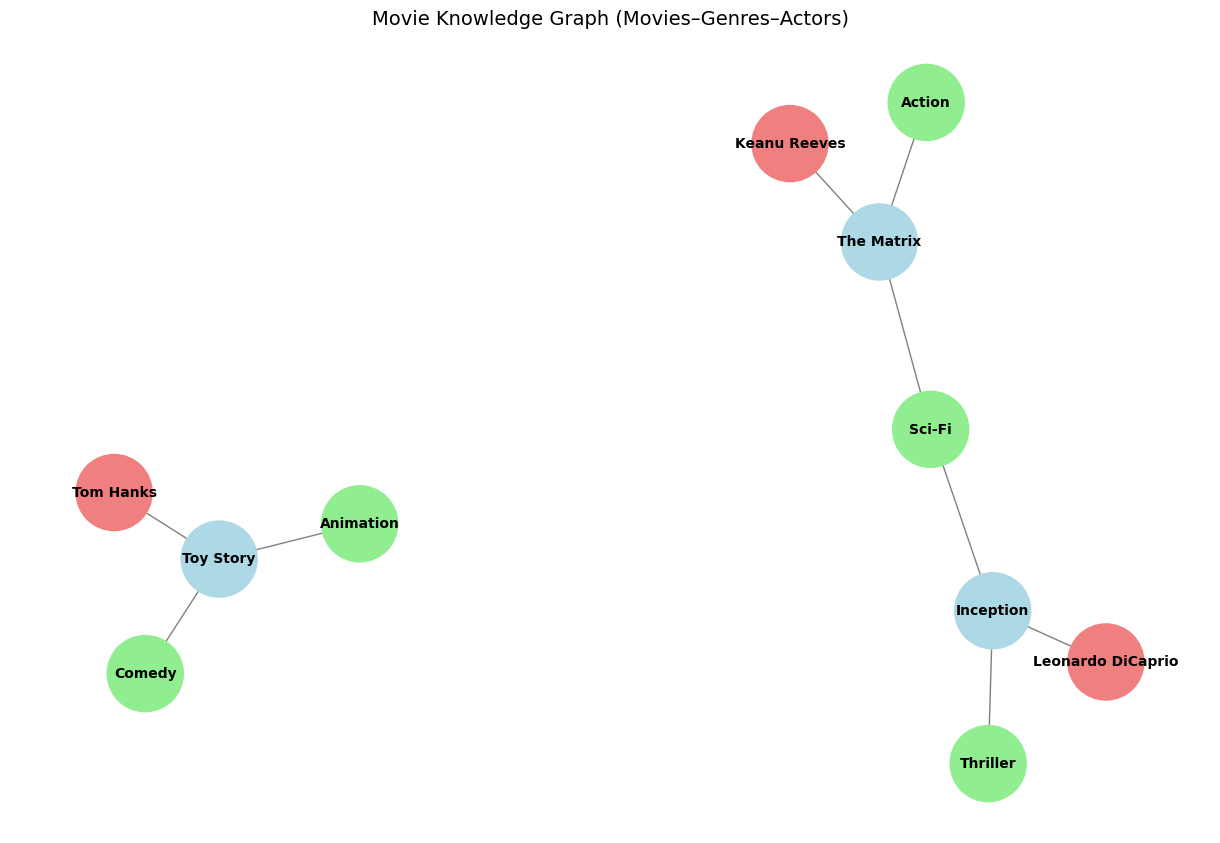

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.Graph()

# Movies → Genres
G.add_edge("Toy Story", "Animation")
G.add_edge("Toy Story", "Comedy")

G.add_edge("The Matrix", "Action")
G.add_edge("The Matrix", "Sci-Fi")

G.add_edge("Inception", "Sci-Fi")
G.add_edge("Inception", "Thriller")

# Movies → Actors
G.add_edge("Toy Story", "Tom Hanks")
G.add_edge("The Matrix", "Keanu Reeves")
G.add_edge("Inception", "Leonardo DiCaprio")

# Define node colors by type
node_colors = []
for node in G.nodes():
    if node in ["Toy Story", "The Matrix", "Inception"]:
        node_colors.append("lightblue")      # Movies
    elif node in ["Animation", "Comedy", "Action", "Sci-Fi", "Thriller"]:
        node_colors.append("lightgreen")     # Genres
    else:
        node_colors.append("lightcoral")     # Actors

# Draw graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=3000,
    font_size=10,
    font_weight="bold",
    edge_color="gray"
)

plt.title("Movie Knowledge Graph (Movies–Genres–Actors)", fontsize=14)
plt.show()

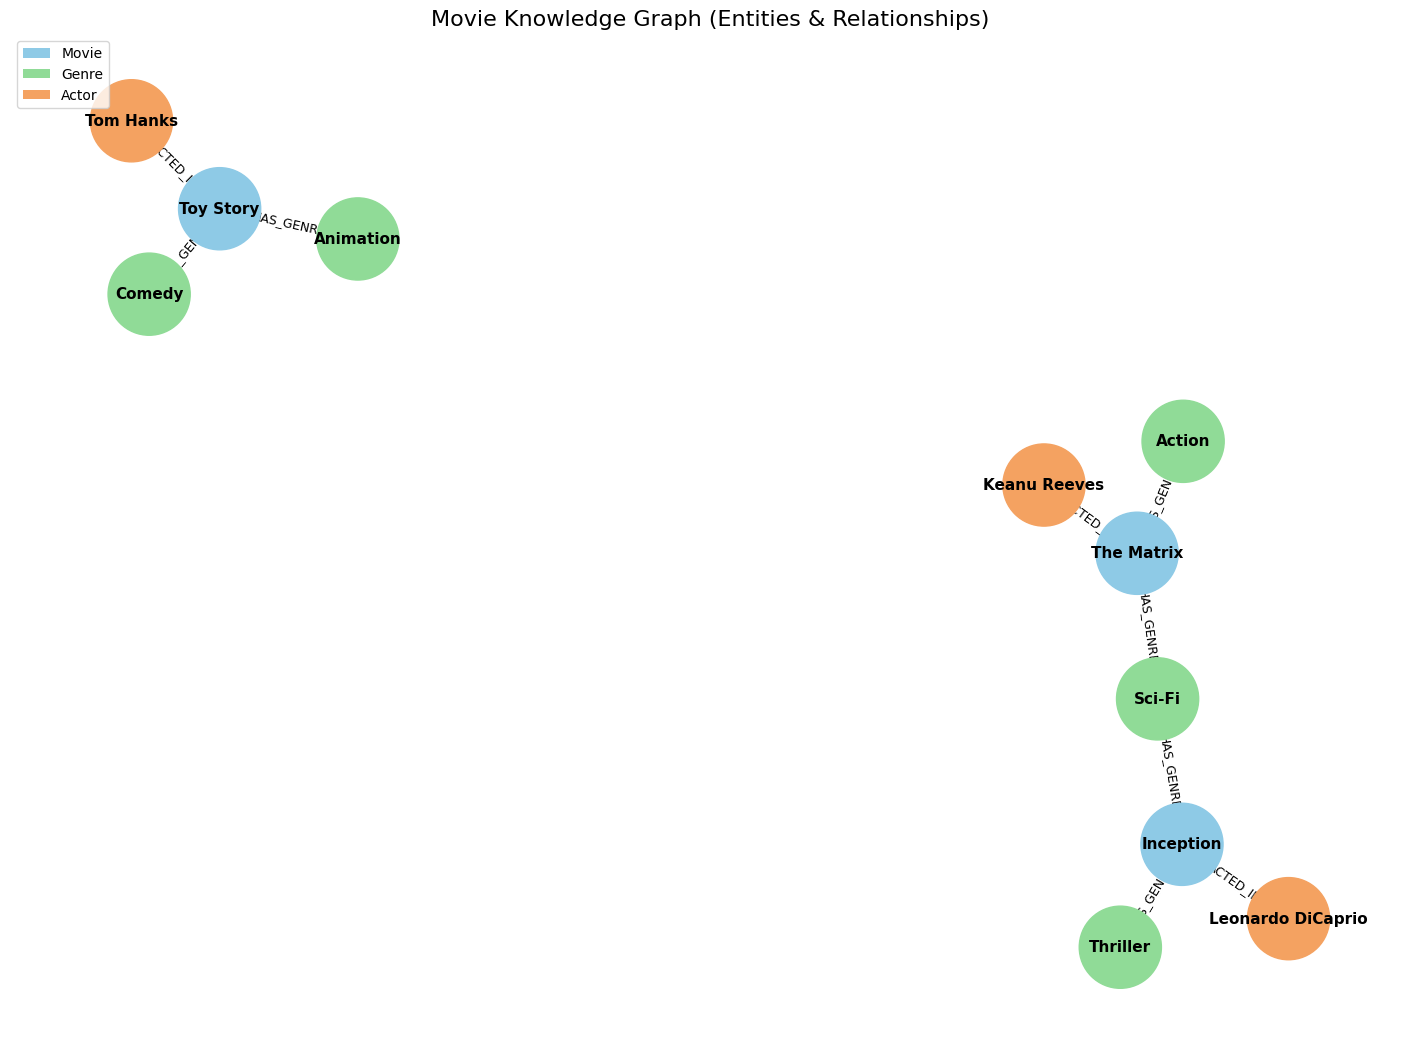

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.Graph()

# -------------------------
# Add edges with semantics
# -------------------------
edges = [
    ("Toy Story", "Animation", "HAS_GENRE"),
    ("Toy Story", "Comedy", "HAS_GENRE"),
    ("Toy Story", "Tom Hanks", "ACTED_IN"),

    ("The Matrix", "Action", "HAS_GENRE"),
    ("The Matrix", "Sci-Fi", "HAS_GENRE"),
    ("The Matrix", "Keanu Reeves", "ACTED_IN"),

    ("Inception", "Sci-Fi", "HAS_GENRE"),
    ("Inception", "Thriller", "HAS_GENRE"),
    ("Inception", "Leonardo DiCaprio", "ACTED_IN")
]

for u, v, rel in edges:
    G.add_edge(u, v, label=rel)

# -------------------------
# Node classification
# -------------------------
movies = ["Toy Story", "The Matrix", "Inception"]
genres = ["Animation", "Comedy", "Action", "Sci-Fi", "Thriller"]

node_colors = []
for node in G.nodes():
    if node in movies:
        node_colors.append("#8ecae6")   # Movie - blue
    elif node in genres:
        node_colors.append("#90db97")   # Genre - green
    else:
        node_colors.append("#f4a261")   # Actor - orange

# -------------------------
# Draw graph
# -------------------------
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=3500,
    font_size=11,
    font_weight="bold",
    edge_color="gray"
)

# Edge labels
edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=9
)

# -------------------------
# Legend
# -------------------------
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#8ecae6", label="Movie"),
    Patch(facecolor="#90db97", label="Genre"),
    Patch(facecolor="#f4a261", label="Actor")
]

plt.legend(handles=legend_elements, loc="upper left")

plt.title("Movie Knowledge Graph (Entities & Relationships)", fontsize=16)
plt.axis("off")
plt.show()

In [ ]:
#Milestone_3

In [ ]:
#Install Required Libraries

pip install faiss-cpu sentence-transformers pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 28.8 MB/s eta 0:00:00


In [ ]:
#Load Data

import pandas as pd

# Use the correct path where the CSV was extracted
movies = pd.read_csv(extracted_csv_path, low_memory=False)

# Keep only required columns
movies = movies[["title", "overview"]].dropna().head(500)

texts = movies["overview"].tolist()
titles = movies["title"].tolist()

print("Documents loaded:", len(texts))

Documents loaded: 500


In [ ]:
#Generate Embeddings

from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(texts, show_progress_bar=True)
embeddings = np.array(embeddings)

print("Embedding shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embedding shape: (500, 384)


In [ ]:
#Store Embeddings in FAISS Vector Database

import faiss

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

print("Total vectors in FAISS index:", index.ntotal)

Total vectors in FAISS index: 500


In [ ]:
#Semantic Search

def semantic_search(query, top_k=3):
    query_vector = model.encode([query])
    distances, indices = index.search(query_vector, top_k)

    results = []
    for idx in indices[0]:
        results.append(titles[idx])
    return results

# Test query
query = "science fiction movies involving technology"
print("Search Results:", semantic_search(query))

Search Results: ['Living in Oblivion', 'Canadian Bacon', 'Little Buddha']


In [ ]:
#Simple RAG Pipeline

def rag_pipeline(query):
    retrieved_docs = semantic_search(query, top_k=2)

    context = " ".join(
        movies[movies["title"] == title]["overview"].values[0]
        for title in retrieved_docs
    )

    # Simulated LLM response
    answer = f"Based on the retrieved context, movies related to your query include: {', '.join(retrieved_docs)}."
    return answer

print(rag_pipeline("AI based science fiction movies"))

Based on the retrieved context, movies related to your query include: Canadian Bacon, Beyond Bedlam.


In [ ]:
#SEMANTIC SEARCH (API-READY)
#pip install faiss-cpu sentence-transformers fastapi uvicorn pandas
#Run IN Bash Terminal

In [ ]:
#Load & Prepare Data (Reusable)

import pandas as pd

# Use the correct path where the CSV was extracted
movies = pd.read_csv(extracted_csv_path, low_memory=False)

movies = movies[["id", "title", "overview"]].dropna().head(1000)

documents = movies.to_dict("records")

print("Documents prepared:", len(documents))

Documents prepared: 1000


In [ ]:
#Generate Embeddings (Persistent)

from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

texts = [doc["overview"] for doc in documents]
embeddings = model.encode(texts, show_progress_bar=True)

embeddings = np.array(embeddings)
print("Embeddings shape:", embeddings.shape)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embeddings shape: (1000, 384)


In [ ]:
#Store in FAISS (Search Engine)

import faiss

dimension = embeddings.shape[1]
faiss_index = faiss.IndexFlatL2(dimension)
faiss_index.add(embeddings)

print("Vectors stored:", faiss_index.ntotal)

Vectors stored: 1000


In [ ]:
#Run Milestone 3 System

# Terminal 1
# python build_index.py

# Terminal 2
# python -m uvicorn app:app --reload

In [ ]:
#Build Embeddings + FAISS Index

import pandas as pd
import numpy as np
import faiss
import pickle
from sentence_transformers import SentenceTransformer

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv(extracted_csv_path, low_memory=False)
df = df[["title", "overview"]].dropna().head(500)

texts = df["overview"].tolist()

# -----------------------------
# Generate embeddings
# -----------------------------
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(texts, show_progress_bar=True)
embeddings = np.array(embeddings)

print("Embedding shape:", embeddings.shape)

# -----------------------------
# Build FAISS index
# -----------------------------
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

print("FAISS index size:", index.ntotal)

# -----------------------------
# Save index + metadata
# -----------------------------
faiss.write_index(index, "movie_index.faiss")

with open("documents.pkl", "wb") as f:
    pickle.dump(df.to_dict("records"), f)

print("✅ FAISS index and documents saved")

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embedding shape: (500, 384)
FAISS index size: 500
✅ FAISS index and documents saved


In [ ]:
#FastAPI Backend – Semantic Search + RAG

from fastapi import FastAPI
from pydantic import BaseModel
import faiss
import pickle
import numpy as np
from sentence_transformers import SentenceTransformer

# -----------------------------
# Load FAISS + data
# -----------------------------
index = faiss.read_index("movie_index.faiss")

with open("documents.pkl", "rb") as f:
    documents = pickle.load(f)

model = SentenceTransformer("all-MiniLM-L6-v2")

# -----------------------------
# App init
# -----------------------------
app = FastAPI(title="Milestone 3: Semantic Search & RAG")

class Query(BaseModel):
    query: str
    top_k: int = 5

# -----------------------------
# Root
# -----------------------------
@app.get("/")
def root():
    return {"status": "Semantic Search API running"}

# -----------------------------
# 🔍 Semantic Search API
# -----------------------------
@app.post("/semantic-search")
def semantic_search(payload: Query):
    query_embedding = model.encode([payload.query])
    distances, indices = index.search(query_embedding, payload.top_k)

    results = []
    for idx in indices[0]:
        results.append({
            "title": documents[idx]["title"],
            "overview": documents[idx]["overview"]
        })

    return {
        "query": payload.query,
        "results": results
    }

# -----------------------------
# 🤖 RAG API (Context-aware)
# -----------------------------
@app.post("/rag-query")
def rag_query(payload: Query):
    query_embedding = model.encode([payload.query])
    distances, indices = index.search(query_embedding, payload.top_k)

    retrieved = [documents[idx] for idx in indices[0]]

    answer = (
        f"Based on semantic analysis of the query "
        f"'{payload.query}', the following movies are relevant:\n\n"
    )

    for doc in retrieved:
        answer += f"- {doc['title']}: {doc['overview'][:160]}...\n"

    return {
        "query": payload.query,
        "answer": answer,
        "sources": [doc["title"] for doc in retrieved]
    }

In [ ]:
#Visual Graph Exploration (Plotly + NetworkX)

import networkx as nx
import plotly.graph_objects as go

# Create graph
G = nx.Graph()

edges = [
    ("The Matrix", "Science Fiction"),
    ("Inception", "Science Fiction"),
    ("Interstellar", "Science Fiction"),
    ("The Matrix", "Action"),
    ("Inception", "Thriller"),
    ("Interstellar", "Drama")
]

G.add_edges_from(edges)

# Layout
pos = nx.spring_layout(G, seed=42)

# Edge traces
edge_x = []
edge_y = []

for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    line=dict(width=1),
    hoverinfo="none",
    mode="lines"
)

# Node traces
node_x = []
node_y = []
node_text = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(node)

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode="markers+text",
    text=node_text,
    textposition="top center",
    marker=dict(size=20),
    hoverinfo="text"
)

# Plot
fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title="Milestone 3 – Knowledge Graph Preview",
        showlegend=False,
        hovermode="closest"
    )
)

fig.show()

In [ ]:
#RUN YOUR GRAPH
# python graph_preview.py